In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"Crop_recommendation.csv")

In [4]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:


columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print("\nFeature:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))


Feature: N
Q1: 21.0
Q3: 84.25
IQR: 63.25
Lower Limit: -73.875
Upper Limit: 179.125
Number of Outliers: 0

Feature: P
Q1: 28.0
Q3: 68.0
IQR: 40.0
Lower Limit: -32.0
Upper Limit: 128.0
Number of Outliers: 138

Feature: K
Q1: 20.0
Q3: 49.0
IQR: 29.0
Lower Limit: -23.5
Upper Limit: 92.5
Number of Outliers: 200

Feature: temperature
Q1: 22.7693746325
Q3: 28.5616539325
IQR: 5.792279300000001
Lower Limit: 14.080955682499999
Upper Limit: 37.2500728825
Number of Outliers: 86

Feature: humidity
Q1: 60.2619528025
Q3: 89.948770755
IQR: 29.6868179525
Lower Limit: 15.731725873750001
Upper Limit: 134.47899768374998
Number of Outliers: 30

Feature: ph
Q1: 5.97169279925
Q3: 6.923642621250002
IQR: 0.9519498220000013
Lower Limit: 4.543768066249998
Upper Limit: 8.351567354250005
Number of Outliers: 57

Feature: rainfall
Q1: 64.55168599999999
Q3: 124.2675078
IQR: 59.715821800000015
Lower Limit: -25.022046700000033
Upper Limit: 213.84124050000003
Number of Outliers: 100


In [7]:
def soil_health(n, p, k, ph, rainfall, temperature, humidity):

    score = 0

    # ==================================
    # CRITICAL FAILURE CONDITIONS
    # ==================================

    critical_count = 0

    if n < 20:
        critical_count += 1

    if p < 20:
        critical_count += 1

    if k < 20:
        critical_count += 1

    if ph < 5.0 or ph > 8.5:
        critical_count += 1

    if rainfall < 30:
        critical_count += 1

    # If too many critical issues → force Poor
    if critical_count >= 2:
        return "Poor"

    # ==================================
    # NORMAL SCORING SYSTEM
    # ==================================

    # Nitrogen
    if 40 <= n <= 100:
        score += 2
    elif 20 <= n < 40 or 100 < n <= 120:
        score += 1

    # Phosphorus
    if 40 <= p <= 100:
        score += 2
    elif 20 <= p < 40 or 100 < p <= 120:
        score += 1

    # Potassium
    if 40 <= k <= 100:
        score += 2
    elif 20 <= k < 40 or 100 < k <= 120:
        score += 1

    # pH
    if 6.0 <= ph <= 7.5:
        score += 2
    elif 5.5 <= ph < 6.0 or 7.5 < ph <= 8.0:
        score += 1

    # Rainfall
    if 80 <= rainfall <= 200:
        score += 2
    elif 50 <= rainfall < 80 or 200 < rainfall <= 250:
        score += 1

    # Temperature
    if 20 <= temperature <= 32:
        score += 2
    elif 15 <= temperature < 20 or 32 < temperature <= 36:
        score += 1

    # Humidity
    if 40 <= humidity <= 80:
        score += 2
    elif 30 <= humidity < 40 or 80 < humidity <= 90:
        score += 1

    # ==================================
    # FINAL DECISION
    # ==================================

    if score >= 11:
        return "Healthy"

    elif score >= 6:
        return "Moderate"

    else:
        return "Poor"

In [8]:
df["Soil_Health"] = df.apply(
    lambda x: soil_health(
        x["N"],
        x["P"],
        x["K"],
        x["ph"],
        x["rainfall"],
        x["temperature"],
        x["humidity"]
    ),
    axis=1
)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Soil_Health"] = le.fit_transform(df["Soil_Health"])

In [10]:
X = df[[
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]]

y = df["Soil_Health"]

In [11]:
from sklearn.model_selection import train_test_split
X = df.drop(["label", "Soil_Health"], axis=1)
y = df["Soil_Health"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(df["Soil_Health"].value_counts())

Soil_Health
1    1161
0     623
2     416
Name: count, dtype: int64


In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7772727272727272

Confusion Matrix:
 [[ 89  45   0]
 [ 20 243  27]
 [  0   6  10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.66      0.73       134
           1       0.83      0.84      0.83       290
           2       0.27      0.62      0.38        16

    accuracy                           0.78       440
   macro avg       0.64      0.71      0.65       440
weighted avg       0.80      0.78      0.79       440



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# Hyperparameter combinations
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Train
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [26]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}


In [27]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [29]:
from sklearn.metrics import accuracy_score

y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 92.27272727272727


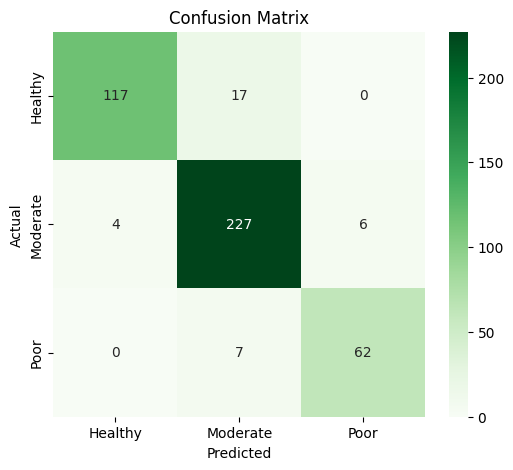

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

     Healthy       0.97      0.87      0.92       134
    Moderate       0.90      0.96      0.93       237
        Poor       0.91      0.90      0.91        69

    accuracy                           0.92       440
   macro avg       0.93      0.91      0.92       440
weighted avg       0.92      0.92      0.92       440



In [34]:
import joblib

joblib.dump(best_rf, "soil_model.pkl")

['soil_model.pkl']

In [18]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = rf.predict(sample)[0]

labels = ["Poor", "Moderate", "Healthy"]

soil_status = labels[prediction]

print("Predicted Soil Health:", soil_status)

Predicted Soil Health: Healthy


c:\Users\Akhilesh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
def detailed_soil_analysis(sample_data):

    recommendations = []

    N = sample_data["N"]
    P = sample_data["P"]
    K = sample_data["K"]
    ph = sample_data["ph"]
    rainfall = sample_data["rainfall"]
    temperature = sample_data["temperature"]
    humidity = sample_data["humidity"]

    #NITROGEN 

    if N < 40:
        recommendations.append(
            "Nitrogen is very low → Plant Clover/Legumes and add compost."
        )

    elif N > 100:
        recommendations.append(
            "Nitrogen is excessive → Reduce nitrogen fertilizers and use crop rotation."
        )

    else:
        recommendations.append(
            "Nitrogen level is balanced."
        )

    #PHOSPHORUS 

    if P < 40:
        recommendations.append(
            "Phosphorus is low → Add bone meal or organic phosphorus fertilizer."
        )

    elif P > 100:
        recommendations.append(
            "Phosphorus is high → Avoid over-fertilization."
        )

    else:
        recommendations.append(
            "Phosphorus level is balanced."
        )

    #POTASSIUM

    if K < 40:
        recommendations.append(
            "Potassium is low → Plant sunflower and apply potassium-rich compost."
        )

    elif K > 100:
        recommendations.append(
            "Potassium is excessive → Reduce potassium fertilizer usage."
        )

    else:
        recommendations.append(
            "Potassium level is balanced."
        )

    #pH

    if ph < 5.5:
        recommendations.append(
            "Soil is acidic → Apply lime treatment to increase pH."
        )

    elif ph > 7.5:
        recommendations.append(
            "Soil is alkaline → Apply sulfur treatment to reduce pH."
        )

    else:
        recommendations.append(
            "Soil pH is healthy."
        )

    #RAINFALL

    if rainfall < 50:
        recommendations.append(
            "Low rainfall detected → Use drip irrigation and drought-resistant crops."
        )

    elif rainfall > 250:
        recommendations.append(
            "Excess rainfall detected → Improve drainage system."
        )

    else:
        recommendations.append(
            "Rainfall condition is suitable."
        )

    #TEMPERATURE

    if temperature < 15:
        recommendations.append(
            "Temperature is too low → Use greenhouse or temperature-resistant crops."
        )

    elif temperature > 35:
        recommendations.append(
            "High temperature detected → Increase irrigation and mulching."
        )

    else:
        recommendations.append(
            "Temperature condition is normal."
        )

    #HUMIDITY

    if humidity < 30:
        recommendations.append(
            "Humidity is very low → Increase irrigation frequency."
        )

    elif humidity > 85:
        recommendations.append(
            "Humidity is too high → Risk of fungal diseases. Improve ventilation."
        )

    else:
        recommendations.append(
            "Humidity level is balanced."
        )

    return recommendations

In [20]:
sample_row = df.iloc[2]

In [21]:
recommendations = detailed_soil_analysis(sample_row)

print("\nDETAILED SOIL RECOMMENDATIONS:\n")

for r in recommendations:
    print("-", r)


DETAILED SOIL RECOMMENDATIONS:

- Nitrogen level is balanced.
- Phosphorus level is balanced.
- Potassium level is balanced.
- Soil is alkaline → Apply sulfur treatment to reduce pH.
- Excess rainfall detected → Improve drainage system.
- Temperature condition is normal.
- Humidity level is balanced.


In [23]:
print(le.classes_)

['Healthy' 'Moderate' 'Poor']


In [24]:
print(df["Soil_Health"].value_counts())

Soil_Health
1    1161
0     623
2     416
Name: count, dtype: int64
